Detected classes: ['Age', 'Cataract', 'Diabetes', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Other']
Custom CNN - Epoch [1/25] | Loss: 2.3819 | Accuracy: 10.06%
Custom CNN - Epoch [2/25] | Loss: 2.1542 | Accuracy: 8.53%
Custom CNN - Epoch [3/25] | Loss: 2.1535 | Accuracy: 7.98%
Custom CNN - Epoch [4/25] | Loss: 2.1492 | Accuracy: 9.93%
Custom CNN - Epoch [5/25] | Loss: 2.1402 | Accuracy: 9.44%
Custom CNN - Epoch [6/25] | Loss: 2.1146 | Accuracy: 13.74%
Custom CNN - Epoch [7/25] | Loss: 2.1086 | Accuracy: 13.90%
Custom CNN - Epoch [8/25] | Loss: 2.0816 | Accuracy: 14.91%
Custom CNN - Epoch [9/25] | Loss: 2.0635 | Accuracy: 16.96%
Custom CNN - Epoch [10/25] | Loss: 2.0571 | Accuracy: 16.34%
Custom CNN - Epoch [11/25] | Loss: 2.0457 | Accuracy: 17.29%
Custom CNN - Epoch [12/25] | Loss: 2.0463 | Accuracy: 16.60%
Custom CNN - Epoch [13/25] | Loss: 2.0335 | Accuracy: 18.39%
Custom CNN - Epoch [14/25] | Loss: 2.0244 | Accuracy: 18.00%
Custom CNN - Epoch [15/25] | Loss: 2.0151 | Accuracy

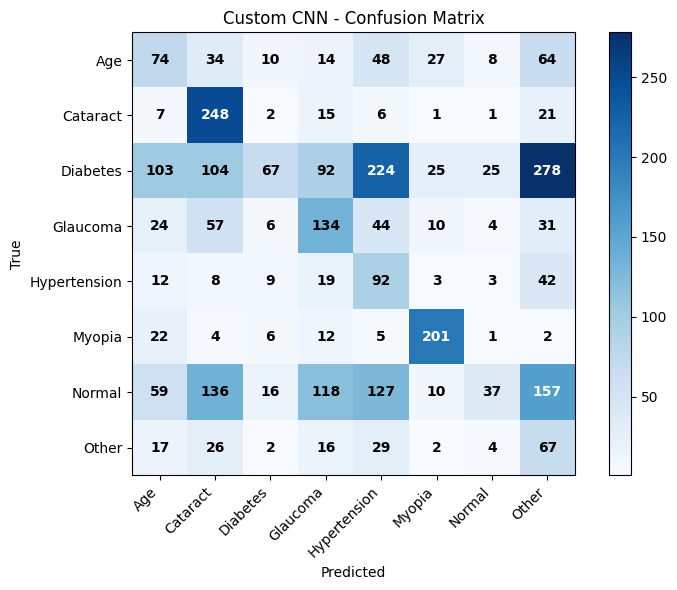

✅ Custom CNN saved as custom_cnn_retina.pth
ResNet50 - Epoch [1/25] | Loss: 1.7151 | Accuracy: 34.90%
ResNet50 - Epoch [2/25] | Loss: 1.4894 | Accuracy: 44.76%
ResNet50 - Epoch [3/25] | Loss: 1.3651 | Accuracy: 52.28%
ResNet50 - Epoch [4/25] | Loss: 1.2866 | Accuracy: 56.22%
ResNet50 - Epoch [5/25] | Loss: 1.2197 | Accuracy: 61.10%
ResNet50 - Epoch [6/25] | Loss: 1.1402 | Accuracy: 64.81%
ResNet50 - Epoch [7/25] | Loss: 1.0731 | Accuracy: 69.63%
ResNet50 - Epoch [8/25] | Loss: 1.0364 | Accuracy: 71.68%
ResNet50 - Epoch [9/25] | Loss: 1.0088 | Accuracy: 73.57%
ResNet50 - Epoch [10/25] | Loss: 0.9776 | Accuracy: 75.10%
ResNet50 - Epoch [11/25] | Loss: 0.9918 | Accuracy: 75.36%
ResNet50 - Epoch [12/25] | Loss: 0.9880 | Accuracy: 74.80%
ResNet50 - Epoch [13/25] | Loss: 0.9848 | Accuracy: 75.42%
ResNet50 - Epoch [14/25] | Loss: 0.9776 | Accuracy: 75.78%
ResNet50 - Epoch [15/25] | Loss: 0.9844 | Accuracy: 75.62%
ResNet50 - Epoch [16/25] | Loss: 0.9891 | Accuracy: 75.98%
ResNet50 - Epoch [17/

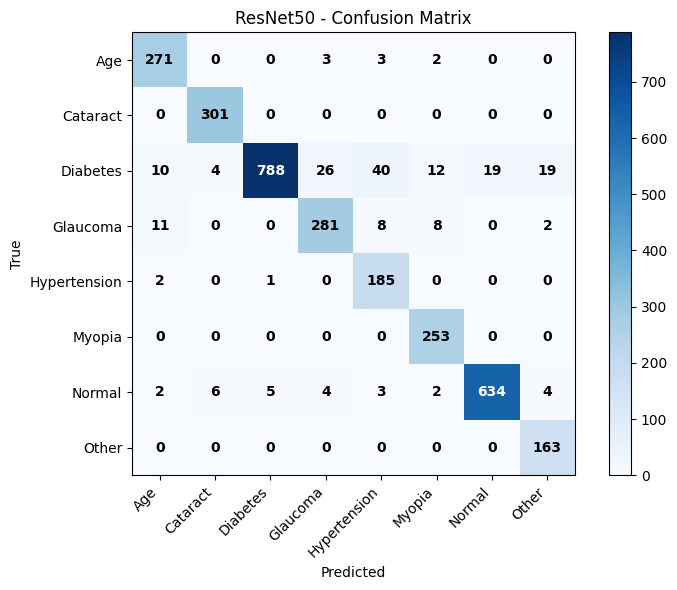

✅ ResNet50 saved as resnet50_retina.pth
VGG19 - Epoch [1/25] | Loss: 1.7547 | Accuracy: 34.57%
VGG19 - Epoch [2/25] | Loss: 1.4927 | Accuracy: 43.20%
VGG19 - Epoch [3/25] | Loss: 1.3037 | Accuracy: 54.92%
VGG19 - Epoch [4/25] | Loss: 1.1368 | Accuracy: 65.14%
VGG19 - Epoch [5/25] | Loss: 1.0168 | Accuracy: 73.27%
VGG19 - Epoch [6/25] | Loss: 0.9157 | Accuracy: 80.60%
VGG19 - Epoch [7/25] | Loss: 0.8479 | Accuracy: 85.51%
VGG19 - Epoch [8/25] | Loss: 0.8038 | Accuracy: 89.03%
VGG19 - Epoch [9/25] | Loss: 0.7778 | Accuracy: 90.72%
VGG19 - Epoch [10/25] | Loss: 0.7751 | Accuracy: 91.05%
VGG19 - Epoch [11/25] | Loss: 0.7626 | Accuracy: 92.61%
VGG19 - Epoch [12/25] | Loss: 0.7691 | Accuracy: 92.12%
VGG19 - Epoch [13/25] | Loss: 0.7617 | Accuracy: 92.15%
VGG19 - Epoch [14/25] | Loss: 0.7657 | Accuracy: 92.55%
VGG19 - Epoch [15/25] | Loss: 0.7692 | Accuracy: 92.74%
VGG19 - Epoch [16/25] | Loss: 0.7793 | Accuracy: 91.73%
VGG19 - Epoch [17/25] | Loss: 0.8023 | Accuracy: 90.85%
VGG19 - Epoch [18

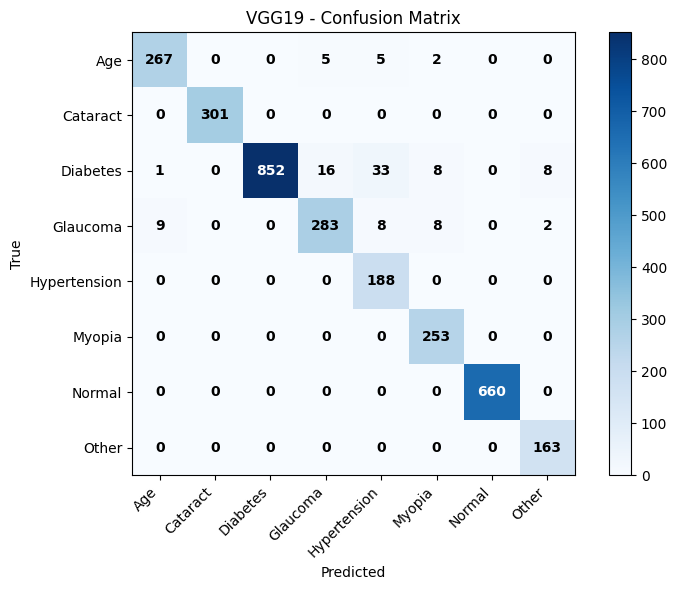

✅ VGG19 saved as vgg19_retina.pth


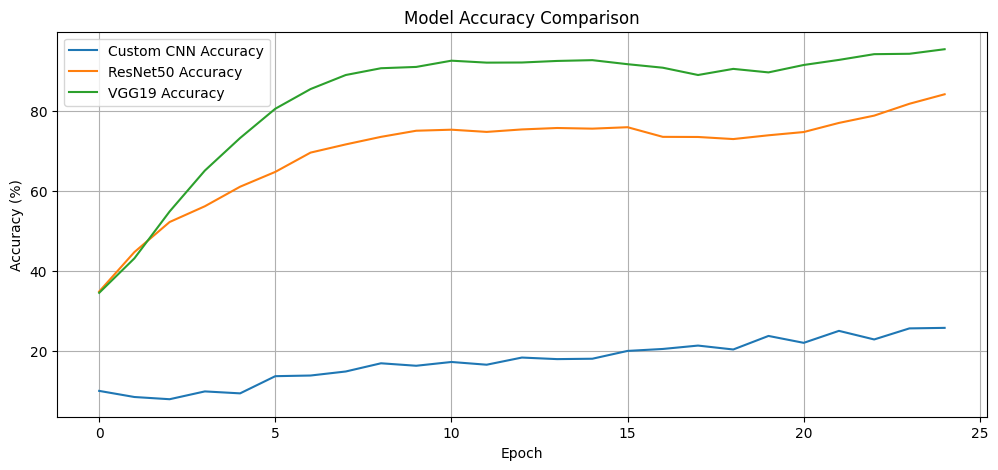

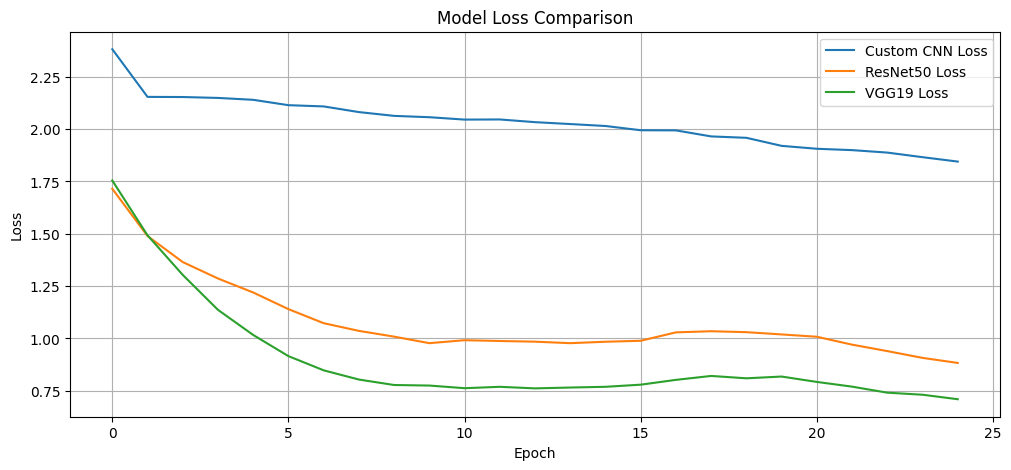

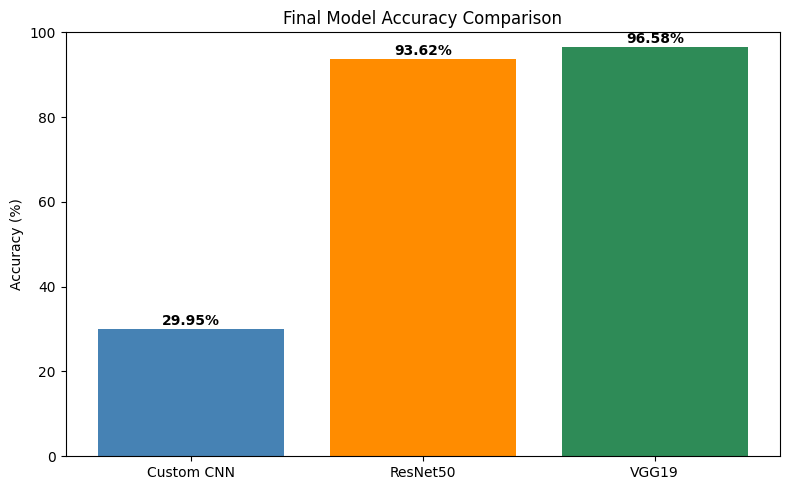

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CONFIGURATION
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "Dataset"  # Folder containing 8 subfolders
num_classes = 8
batch_size = 64
epochs = 25
base_lr = 0.001
fine_tune_lr = 1e-5
image_size = 224

# ============================================================
# DATA AUGMENTATION
# ============================================================
from torchvision.transforms import InterpolationMode

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============================================================
# DATASET LOADING
# ============================================================
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
class_names = full_dataset.classes
print("Detected classes:", class_names)

train_dataset = full_dataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# ============================================================
# CLASS WEIGHT BALANCING
# ============================================================
labels = [label for _, label in full_dataset.imgs]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# ============================================================
# MODEL DEFINITIONS
# ============================================================
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)  # After 3 pools: 224/8 = 28
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = self.pool(nn.functional.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# ============================================================
# TRAIN + EVALUATE FUNCTION
# ============================================================
def train_and_evaluate(model, model_name, train_loader, train_eval_loader):
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=base_lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

    train_losses, train_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        scheduler.step()

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        print(f"{model_name} - Epoch [{epoch+1}/{epochs}] | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # Evaluation
    full_dataset.transform = eval_transform
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in train_eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    final_acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    print(f"\n{model_name} - Final Accuracy: {final_acc:.2f}%")
    print(f"{model_name} - Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=10, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    # Save Model
    torch.save(model.state_dict(), f"{model_name.lower().replace(' ', '_')}_retina.pth")
    print(f"✅ {model_name} saved as {model_name.lower().replace(' ', '_')}_retina.pth")

    return {
        "name": model_name,
        "loss": train_losses,
        "accuracy": train_accs,
        "final_acc": final_acc
    }


# ============================================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================================
results = []

custom_cnn = CustomCNN()
results.append(train_and_evaluate(custom_cnn, "Custom CNN", train_loader, train_eval_loader))

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in resnet.parameters():
    param.requires_grad = False
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
results.append(train_and_evaluate(resnet, "ResNet50", train_loader, train_eval_loader))

vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
for param in vgg19.parameters():
    param.requires_grad = False
in_features = vgg19.classifier[0].in_features
vgg19.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
results.append(train_and_evaluate(vgg19, "VGG19", train_loader, train_eval_loader))

# ============================================================
# COMPARISON PLOT
# ============================================================
plt.figure(figsize=(12, 5))
for result in results:
    plt.plot(result["accuracy"], label=f"{result['name']} Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
for result in results:
    plt.plot(result["loss"], label=f"{result['name']} Loss")
plt.title("Model Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Bar chart for final accuracies
plt.figure(figsize=(8, 5))
names = [r["name"] for r in results]
final_accs = [r["final_acc"] for r in results]
plt.bar(names, final_accs, color=['steelblue', 'darkorange', 'seagreen'])
plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for i, acc in enumerate(final_accs):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
